In [2]:
import numpy as np
import matplotlib.pyplot as plt

import Voronoi as Voronoi
import MonteCarlo as MonteCarlo
import Graphene as Graphene
import LammpsWriter as LammpsWriter
import Run_anneal as Run_anneal
from Analyze_Observable import analyze_observable, plot_phase_diagram
%load_ext autoreload
%autoreload 2

Monte Carlo Sweeps: 100%|██████████| 200000/200000 [00:28<00:00, 6976.60it/s]


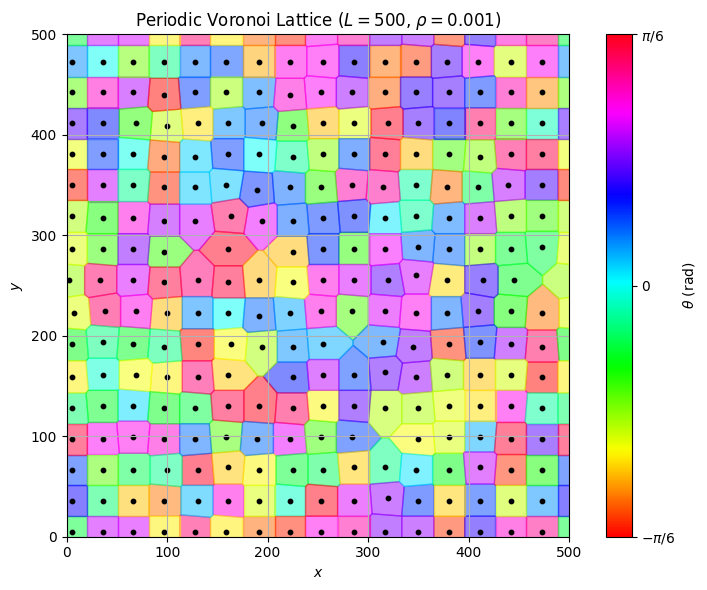

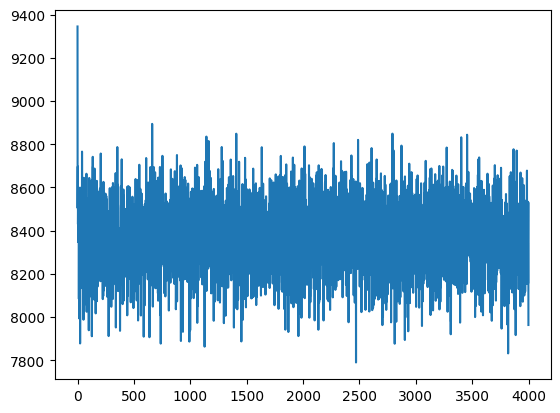

In [12]:
T = 20
L = 500
rho = 0.001
alpha = 2.36
beta_RS = -0.12
epsilon = 0

vor = Voronoi.PeriodicVoronoi(L, rho)

thetas, energy = MonteCarlo.monte_carlo(vor.theta, vor.adj_i, vor.adj_j, vor.adj_length, 1/T, epsilon, rho, alpha, beta_RS, 200_000)
vor.theta = thetas
vor.plot()
plt.show()

plt.plot(energy)
plt.show()

# graphene = Graphene.GrapheneCrystal(vor, a=1.42)
# graphene.plot_atoms()
# plt.show()
# graphene.plot_bonds()
# plt.show()

In [13]:
L = 500
epsilon = 0
rho = 0.001

analyze_observable(L, epsilon, rho)

In [6]:
epsilon = 0

phase_data = {
    0.00001: {
        "T": [40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200],
        "phases": ["s", "s", "h", "h", "h", "h", "h", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.000005: {
        "T": [40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250],
        "phases": ["s", "s", "s", "s", "s", "s", "h", "h", "h", "h", "h", "h", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.000007: {
        "T": [40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250],
        "phases": ["s", "s", "s", "s", "h", "h", "h", "h", "h", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.00003: {
        "T": [30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150],
        "phases": ["s", "s", "h", "h", "l", "l", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.00005: {
        "T": [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120],
        "phases": ["s", "s", "h", "h", "l", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.001: {
        "T": [1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
        "phases": ["s", "s", "s", "h", "h", "h", "l", "l", "l", "l", "l"]
    },
    0.0001: {
        "T": [10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100],
        "phases": ["s", "s", "h", "h", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.0002: {
        "T": [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60],
        "phases": ["s", "h", "h", "h", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.0005: {
        "T": [7, 8, 10, 15, 20, 25, 30, 35, 40],
        "phases": ["s", "h", "h", "l", "l", "l", "l", "l", "l"]
    }
}

plot_phase_diagram(phase_data, epsilon)